
Description:
这是基于`ManipulabilityGraph.py`的更新版本,所读取的数据文件只包含所需的contact point

上游代码:
所读取的数据文件根据`_DiffPDDeformability.py`生成


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as patches


# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [6]:
marker_idx = 95
mani_list = [5, 76, 118]

mani_dx_dy = np.zeros((121*2, 2*len(mani_list)))

# 读取数据
for idx in mani_list:
    dx_dy_tmp = np.loadtxt(f'dx_dy-contact_idx_{idx}.csv', delimiter=',')
    mani_dx_dy[:, 2*mani_list.index(idx):2*(mani_list.index(idx)+1)] = dx_dy_tmp
    
np.savetxt('mani_dx_dy-marker_95.csv', mani_dx_dy, fmt='%f', delimiter=',')

In [7]:
mani_dx_dy = np.loadtxt('mani_dx_dy-marker_95.csv', delimiter=',')

mani_j = mani_dx_dy[marker_idx*2:marker_idx*2+2, :]

area_list = []
for idx in range(len(mani_list)):
    j = mani_j[:, idx*2:idx*2+2]
    u, s, v = np.linalg.svd(j)
    area_tmp = s[0] * s[1] * np.pi / 2
    area_list.append(area_tmp)
    print(mani_list[idx], area_tmp, s)

5 0.008910924194048597 [0.6117623 0.009273 ]
76 0.2866122007040753 [0.60210686 0.30304088]
118 0.4179017918412799 [0.66384314 0.40076416]


In [1]:
"""
得到可操作性图的相关参数
"""
top_dict_list = []
right_dict_list = []
bottom_dict_list = []

# direction1, direction2 = np.array([1, 0]), np.array([-1, 0])      # top
direction1, direction2 = np.array([-1, 0]), np.array([1, 0])      # bottom
# direction1, direction2 = np.array([0, -1]), np.array([0, 1])        # right

points_list = [118]
for idx_value in points_list:
    idx = mani_list.index(idx_value)
    j_tmp = mani_j[:, idx*2:idx*2+2]

    j_direction1 = np.dot(j_tmp, direction1)
    j_direction2 = np.dot(j_tmp, direction2)

    u, s, v = np.linalg.svd(j_tmp)
    yflip = np.array([[1, 0], [0, -1]])
    if np.linalg.det(u) < 0 and np.linalg.det(v) < 0:
        u_yflip = u @ yflip
        v_yflip = v @ yflip
    elif np.linalg.det(u) < 0:
        raise ValueError('u is not a rotation matrix')
    elif np.linalg.det(v) < 0:
        raise ValueError('v is not a rotation matrix')
    else:
        u_yflip = u
        v_yflip = v
    
    end_x = np.dot(np.diag(s)@v_yflip.T, direction1)
    end_xx = np.dot(np.diag(s)@v_yflip.T, direction2)
    
    ang1 = np.degrees(np.arctan2(end_x[1], end_x[0]))
    ang2 = np.degrees(np.arctan2(end_xx[1], end_xx[0]))
    
    rot_ang = np.degrees(np.arctan2(u_yflip[1,0], u_yflip[0,0]))
    
    print(f'Point {idx_value} -------------------------------------------')
    print('rot', rot_ang)
    print('Arc range', ang1, ang2)
    print('Area', s)
    
    dict_tmp = {'s': s, 'rot': rot_ang, 'arc_range': [ang1, ang2], 'j_direction1': j_direction1, 'j_direction2': j_direction2, 'idx': idx_value}
    bottom_dict_list.append(dict_tmp)

NameError: name 'np' is not defined

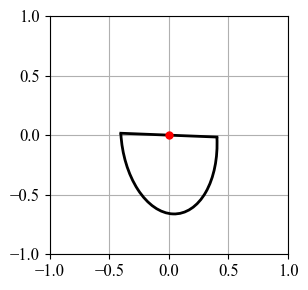

In [13]:
"""
绘制指定操作点的可操作性图
point idx = 5, 76, 118. 直接修改points_list中的数值即可
"""
dict_list = bottom_dict_list
fig, axes = plt.subplots(1, 1, figsize=(6, 3), dpi=100)
N = 0
ax = axes
point_idx = dict_list[N]['idx']

axes.tick_params(axis='both', which='major', labelsize=12)    # 设置刻度标签大小

s = dict_list[N]['s']
rot_ang = dict_list[N]['rot']
ang1, ang2 = dict_list[N]['arc_range']
j_direction1 = dict_list[N]['j_direction1']
j_direction2 = dict_list[N]['j_direction2']

# 定义椭圆圆弧的参数:中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=ang1, theta2=ang2, color='k', linewidth=2)
ellipse_arc.set_zorder(2)

# 将椭圆圆弧添加到子图上
ax.add_patch(ellipse_arc)
ax.plot([0., j_direction1[0]], [0., j_direction1[1]], color='k', linewidth=2, zorder=2)
ax.plot([0., j_direction2[0]], [0., j_direction2[1]], color='k', linewidth=2, zorder=2)
ax.scatter(0, 0, color='r', s=25, zorder=3)

ax.set_xlim([-1., 1.])
ax.set_ylim([-1., 1.])
ax.set_aspect('equal', adjustable='box')
ax.grid(True, zorder=0)

plt.tight_layout()
plt.show()